In [ ]:
#installing kaggle liraries
! pip install kaggle

In [ ]:
#configuring the path of kaggle.jason file
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


# Importing Twitter Sentiment **Dataset**

In [ ]:
# API to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#Extracting the compressed Dataset
from zipfile import ZipFile
dataset = '/content/sentiment140.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


# Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import re
# Download required resources for NLTK
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
# Make sure scikit-learn is updated
!pip install --upgrade scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer # Fixed typo here: It's TfidfVectorizer, not TfidVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
#printing the stopwords in english
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

**Data** **Processing**

In [ ]:
# loading the data from csv file to dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1')

In [ ]:
# checking the number of rows and columns
twitter_data.shape

(1599999, 6)

In [ ]:
#printing the first 5 rows of dataframe
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
#naming the coluns and reading the dataset again
column_names = ['target', 'ids', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',names= column_names, encoding='ISO-8859-1')

In [ ]:
# checking the number of rows and columns
twitter_data.shape

(1600000, 6)

In [ ]:
#printing the first 5 rows of dataframe
twitter_data.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# counting the number of missing values in dataset
twitter_data.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [ ]:
# checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


# CONVERT THE TARGET "4" TO "1"

In [ ]:
twitter_data.replace({'target':{4:1}}, inplace=True)

In [ ]:
# checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


# 0--> Negative Tweet
# 1--> Positive Tweet

**Stemming**

stemming is a process of reducing a word to its Root word.

eg. actoress, actor, acting = act

In [ ]:
port_stem = PorterStemmer()


In [ ]:
def stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]',' ',content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content = ' '.join(stemmed_content)
  return stemmed_content

In [ ]:
twitter_data['stemmed_content'] = twitter_data['text'].apply(stemming) # huge time to execte because of a big data

In [ ]:
twitter_data.head()

,target,ids,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoot http twitpic com zl awww bummer sho...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset updat facebook text might cri result sch...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichan dive mani time ball manag save rest g...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,whole bodi feel itchi like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclass behav mad see


In [ ]:
print(twitter_data['stemmed_content'])

0          switchfoot http twitpic com zl awww bummer sho...
1          upset updat facebook text might cri result sch...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                              nationwideclass behav mad see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdb com cool hear old walt interview http b...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: stemmed_content, Length: 1600000, dtype: object


In [ ]:
#seperating the data and labels
X = twitter_data['stemmed_content'].values
Y = twitter_data['target'].values

In [ ]:
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [ ]:
print(Y)

[0 0 0 ... 1 1 1]


Splitting the data to training data and test data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(1600000,) (1280000,) (320000,)


In [ ]:
print(X_train)

['watch saw iv drink lil wine' 'hatermagazin'
 'even though favourit drink think vodka coke wipe mind time think im gonna find new drink'
 ... 'eager monday afternoon'
 'hope everyon mother great day wait hear guy store tomorrow'
 'love wake folger bad voic deeper']


In [ ]:
print(X_test)

['mmangen fine much time chat twitter hubbi back summer amp tend domin free time'
 'ah may show w ruth kim amp geoffrey sanhueza'
 'ishatara mayb bay area thang dammit' ...
 'destini nevertheless hooray member wonder safe trip' 'feel well'
 'supersandro thank']


In [ ]:
#converting the textual data to numerical data
vectorizer = TfidfVectorizer()
vectorizer.fit(X_train)

X_train = vectorizer.transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453092 stored elements and shape (1280000, 461488)>
  Coords	Values
  (0, 109306)	0.3753708587402299
  (0, 185193)	0.5277679060576009
  (0, 235045)	0.41996827700291095
  (0, 354543)	0.3588091611460021
  (0, 436713)	0.27259876264838384
  (0, 443066)	0.4484755317023172
  (1, 160636)	1.0
  (2, 77929)	0.3128408075034635
  (2, 109306)	0.45911764137283173
  (2, 124484)	0.18921559608014152
  (2, 129411)	0.2907419272795715
  (2, 132311)	0.20289715703997943
  (2, 150715)	0.1880385058320795
  (2, 178061)	0.1619010109445149
  (2, 266729)	0.24123230668976978
  (2, 288470)	0.16786949597862735
  (2, 406399)	0.32105459490875526
  (2, 407301)	0.18709338684973034
  (2, 409143)	0.15169282335109838
  (2, 433560)	0.32965958980285653
  (2, 443430)	0.33485996702528453
  (3, 56476)	0.5200465453608686
  (3, 151770)	0.278559647704793
  (3, 158711)	0.4456939372299574
  (3, 172421)	0.37464146922154384
  :	:
  (1279996, 291078)	0.17981734369155505
  (

In [ ]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289192 stored elements and shape (320000, 461488)>
  Coords	Values
  (0, 15110)	0.1719352837797837
  (0, 31168)	0.1624772418052177
  (0, 67828)	0.26800375270827315
  (0, 106069)	0.36555450010904555
  (0, 132364)	0.255254889555786
  (0, 138164)	0.23688292264071406
  (0, 171378)	0.2805816206356074
  (0, 271016)	0.45356623916588285
  (0, 279082)	0.17825180109103442
  (0, 388348)	0.2198507607206174
  (0, 398906)	0.34910438732642673
  (0, 409143)	0.3143047059807971
  (0, 420984)	0.17915624523539805
  (1, 6463)	0.30733520460524466
  (1, 15110)	0.211037449588008
  (1, 145393)	0.575262969264869
  (1, 217562)	0.40288153995289894
  (1, 256777)	0.28751585696559306
  (1, 348135)	0.4739279595416274
  (1, 366203)	0.24595562404108307
  (2, 22532)	0.3532582957477176
  (2, 34401)	0.37916255084357414
  (2, 89448)	0.36340369428387626
  (2, 183312)	0.5892069252021465
  (2, 256834)	0.2564939661498776
  :	:
  (319994, 443794)	0.2782185641032538


# **Training the Machine Learning**

Logistic regression

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# **Model Evaluation**
Accuracy score

In [ ]:
# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)

In [ ]:
print('Accuracy score on the training data: ',training_data_accuracy)

Accuracy score on the training data:  0.79871953125


In [ ]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,Y_test)

In [ ]:
print('Accuracy score on the training data: ',training_data_accuracy)

Accuracy score on the training data:  0.79871953125


Model accuracy = 79.87%


Saving the trained model

In [ ]:
import pickle

In [ ]:
filename='trained_model.sav'
pickle.dump(model,open(filename,'wb'))

Using the saved model for future Predictions.

In [ ]:
#loading the trained model.
loaded_model= pickle.load(open('/content/trained_model.sav','rb'))

In [ ]:
X_new = X_test[200]
print(Y_test[200])
prediction= loaded_model.predict(X_new)
print(prediction)
if (prediction[0]==0):
  print('negative tweet')
else:
  print('positive tweet')

1
[1]
positive tweet


In [ ]:
X_new=X_test[3]
print(Y_test[3])
prediction= loaded_model.predict(X_new)
print(prediction)
if (prediction[0]==0):
  print('negative tweet')
else:
  print('positive tweet')

0
[0]
negative tweet


In [ ]:
import pandas as pd

# Try ISO-8859-1 encoding (works for Twitter data)
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1')

print(df.head())



   0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY _TheSpecialOne_  \
0  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   scotthamilton   
1  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY        mattycus   
2  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         ElleCTF   
3  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          Karoli   
4  0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY        joy_wolf   

  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D  
0  is upset that he can't update his Facebook by ...                                                                   
1  @Kenichan I dived many times for the ball. Man...                                                                   
2    my whole body feels itchy and like its on fire                                                                    
3  @nationwideclass no, it's not behaving at all....           

                                                text sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  Negative
1  is upset that he can't update his Facebook by ...  Negative
2  @Kenichan I dived many times for the ball. Man...  Negative
3    my whole body feels itchy and like its on fire   Negative
4  @nationwideclass no, it's not behaving at all....  Negative


/tmp/ipykernel_10122/2683515228.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='coolwarm')


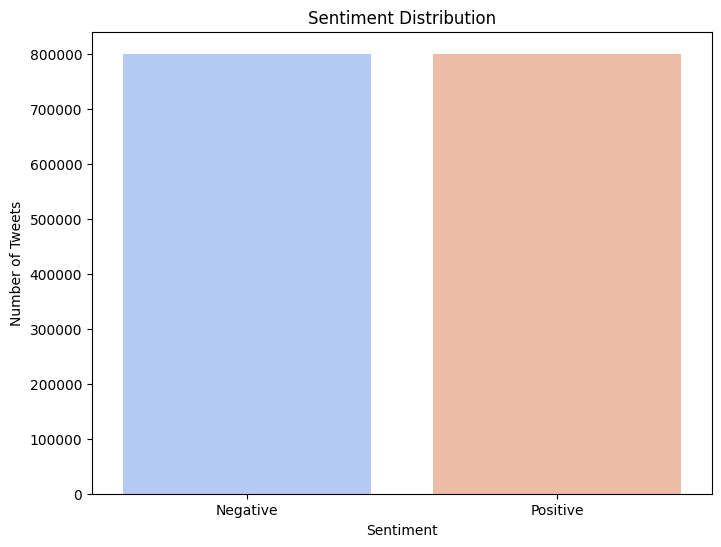

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1', header=None)

# Rename columns properly
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

# Map the target: 0 = Negative, 4 = Positive
df['sentiment'] = df['target'].map({0: 'Negative', 4: 'Positive'})

# Show only 5 elements
print(df[['text', 'sentiment']].head())

# Plot the sentiment distribution
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='sentiment', palette='coolwarm')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()


Sentiment Counts:
sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64


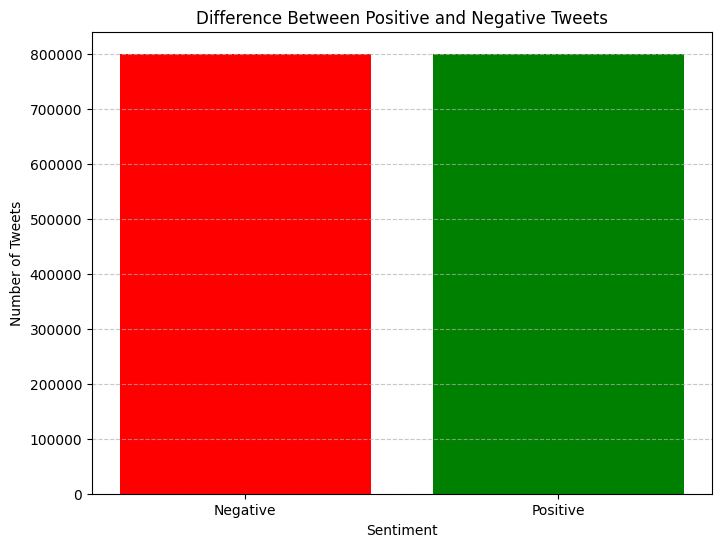

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare your dataset
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='ISO-8859-1', header=None)
df.columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df['sentiment'] = df['target'].map({0: 'Negative', 4: 'Positive'})

# Count the number of Positive and Negative tweets
sentiment_counts = df['sentiment'].value_counts()

# Print the result
print("Sentiment Counts:")
print(sentiment_counts)

# Bar graph showing difference
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['red', 'green'])
plt.title('Difference Between Positive and Negative Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


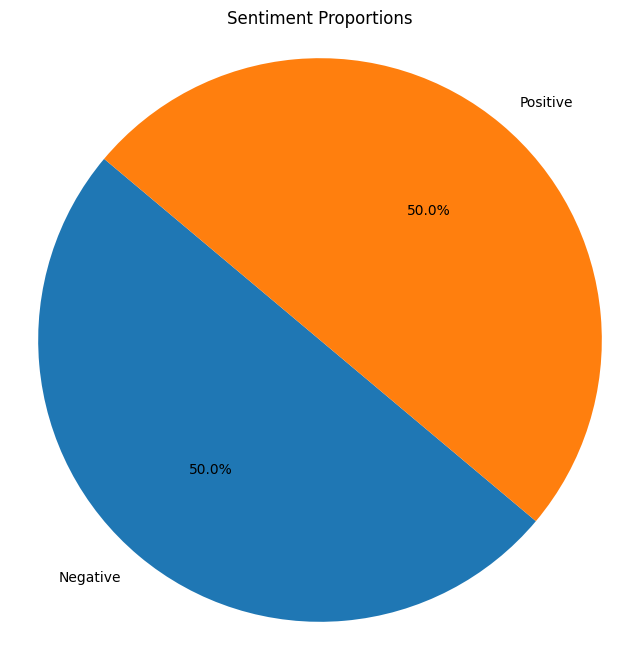

In [70]:
sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Sentiment Proportions')
plt.axis('equal')

plt.savefig("sentiment_pie_chart.png")  # for GitHub
plt.show()

In [71]:
import numpy as np
import pandas as pd

# Add synthetic demographic columns
np.random.seed(42)
n = len(df)

df['Age'] = np.random.randint(18, 70, size=n)
df['Income'] = np.random.normal(loc=60000, scale=15000, size=n).clip(20000, 150000)
df['Gender'] = np.random.choice(['M', 'F'], size=n)
df['Membership'] = np.random.choice(['Bronze', 'Silver', 'Gold'], size=n, p=[0.2, 0.5, 0.3])
df['City'] = np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Pune'], size=n)

# Create Age_Group
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 35, 60, np.inf], labels=['Child', 'Young Adult', 'Adult', 'Senior'])

# Standardized Income (Z-score)
df['Income_Standardized'] = (df['Income'] - df['Income'].mean()) / df['Income'].std()

# Income Bin (Quantile-based)
df['Income_Bin'] = pd.qcut(df['Income'], q=3, labels=['Low', 'Medium', 'High'])


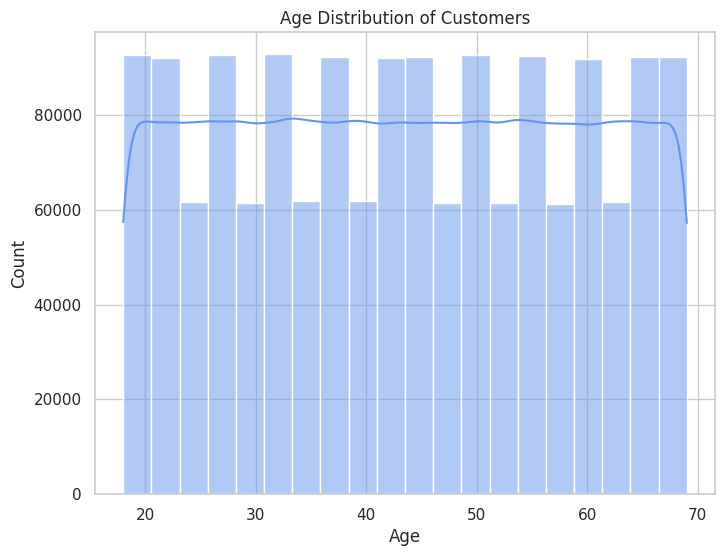

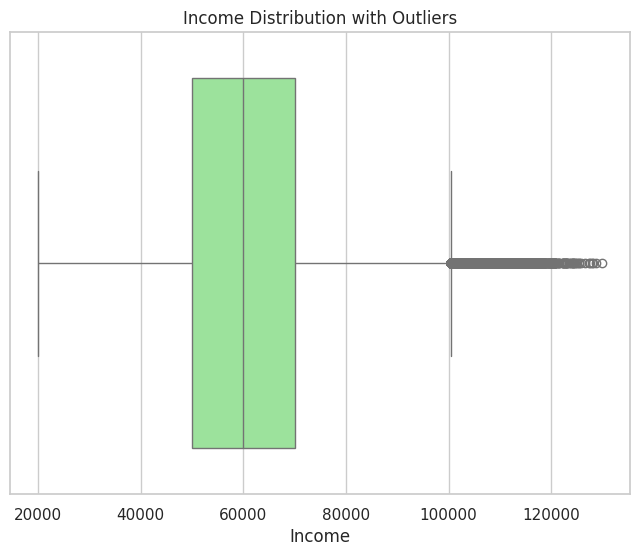

/tmp/ipykernel_10122/4143925610.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Membership', data=df, palette='Set2')


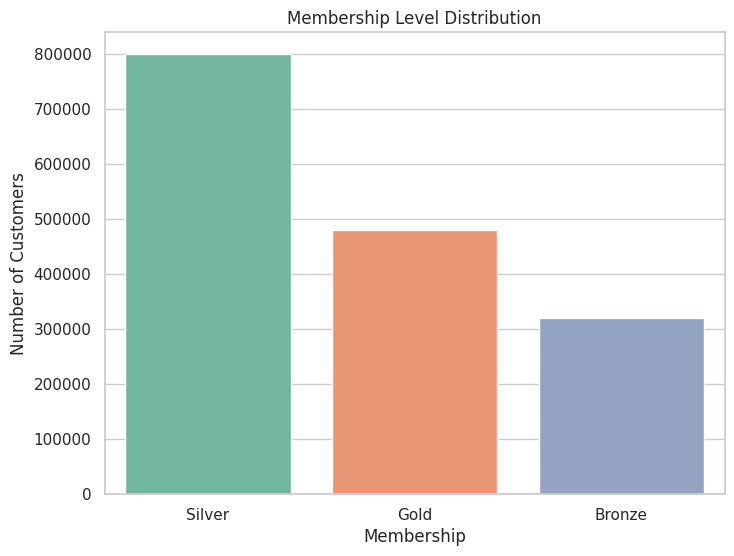

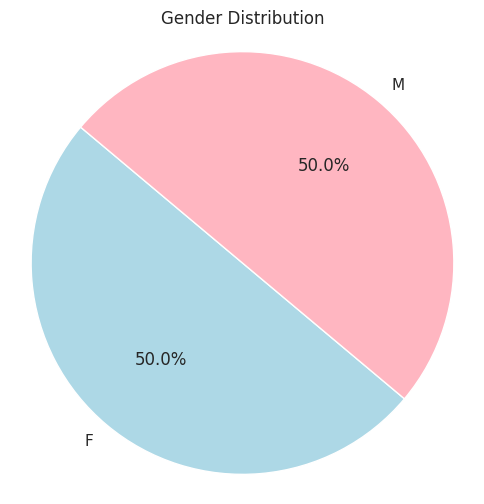

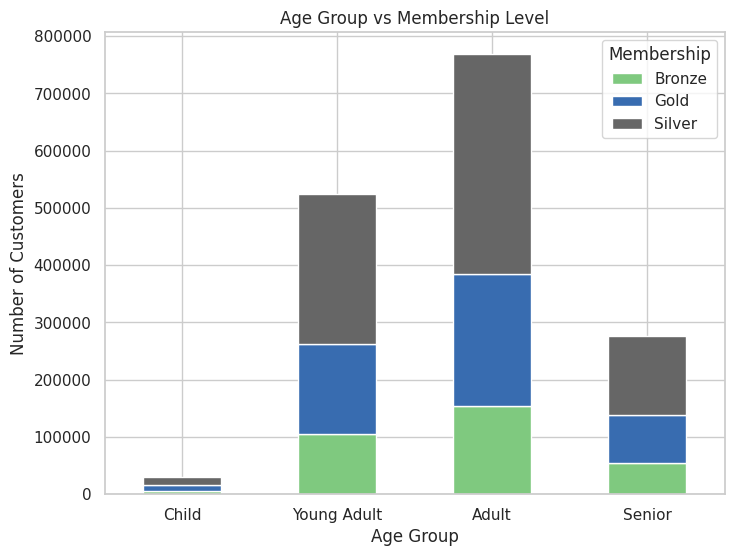

/tmp/ipykernel_10122/4143925610.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Age_Group', y='Income', data=df, palette='Set3')


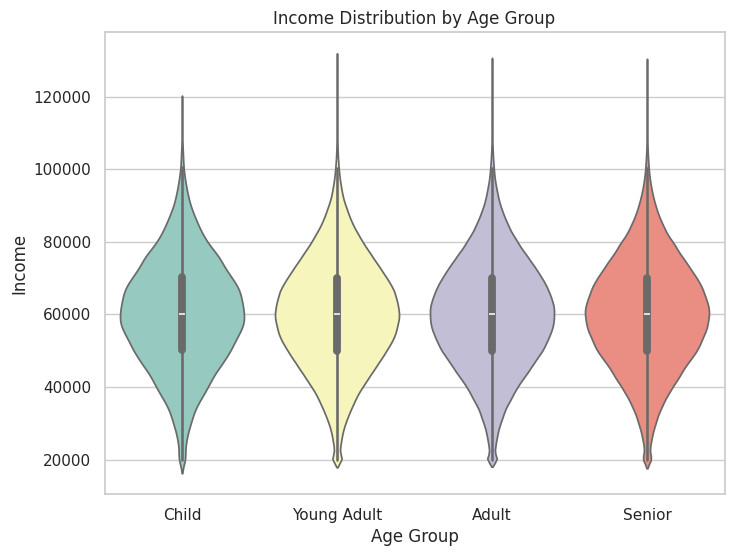

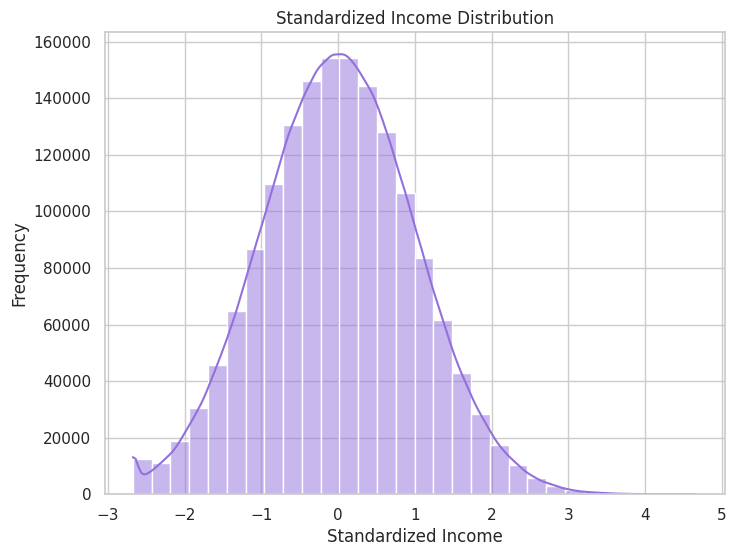

/tmp/ipykernel_10122/4143925610.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette='Blues')


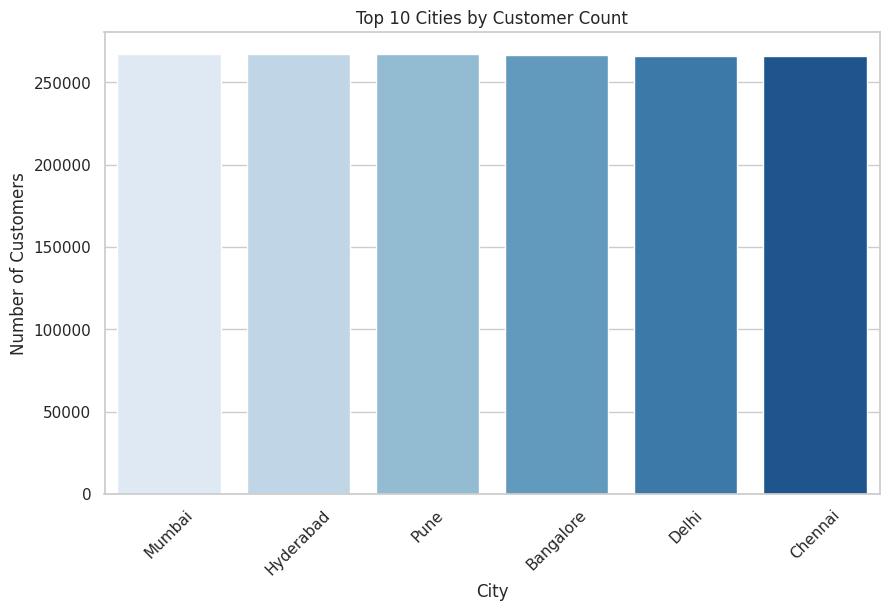

/tmp/ipykernel_10122/4143925610.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Income_Bin', data=df, palette='coolwarm')


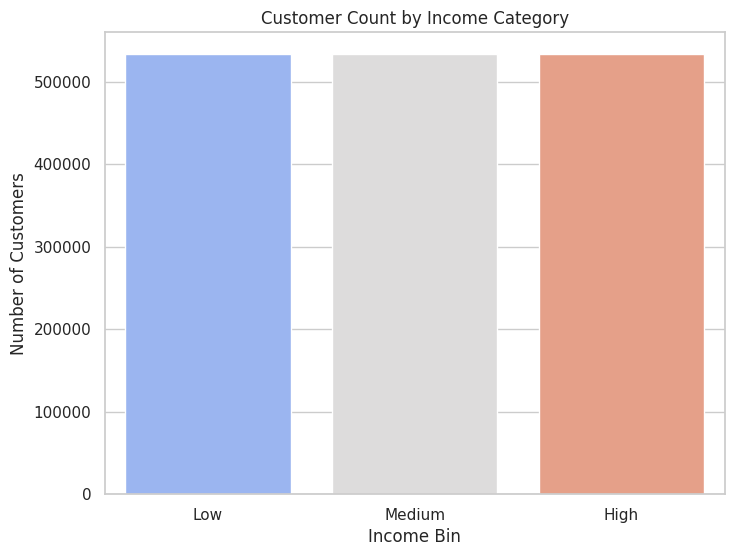

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Setup plot style
sns.set(style="whitegrid")

# 1. Age Distribution (Histogram)
plt.figure(figsize=(8,6))
sns.histplot(df['Age'], bins=20, kde=True, color='cornflowerblue')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 2. Income Distribution (Boxplot)
plt.figure(figsize=(8,6))
sns.boxplot(x='Income', data=df, color='lightgreen')
plt.title('Income Distribution with Outliers')
plt.xlabel('Income')
plt.show()

# 3. Membership Level Count (Bar Chart)
plt.figure(figsize=(8,6))
sns.countplot(x='Membership', data=df, palette='Set2')
plt.title('Membership Level Distribution')
plt.xlabel('Membership')
plt.ylabel('Number of Customers')
plt.show()

# 4. Gender Distribution (Pie Chart)
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'lightpink'])
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

# 5. Age Group vs Membership (Stacked Bar Chart)
cross_tab = pd.crosstab(df['Age_Group'], df['Membership'])
cross_tab.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Accent')
plt.title('Age Group vs Membership Level')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.legend(title='Membership')
plt.xticks(rotation=0)
plt.show()

# 6. Income by Age Group (Violin Plot)
plt.figure(figsize=(8,6))
sns.violinplot(x='Age_Group', y='Income', data=df, palette='Set3')
plt.title('Income Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Income')
plt.show()

# 7. Standardized Income Distribution (Histogram)
plt.figure(figsize=(8,6))
sns.histplot(df['Income_Standardized'], bins=30, kde=True, color='mediumpurple')
plt.title('Standardized Income Distribution')
plt.xlabel('Standardized Income')
plt.ylabel('Frequency')
plt.show()

# 8. City-Wise Customer Count (Bar Plot)
top_cities = df['City'].value_counts().nlargest(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.index, y=top_cities.values, palette='Blues')
plt.title('Top 10 Cities by Customer Count')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

# 9. Income Binning (Count Plot)
plt.figure(figsize=(8,6))
sns.countplot(x='Income_Bin', data=df, palette='coolwarm')
plt.title('Customer Count by Income Category')
plt.xlabel('Income Bin')
plt.ylabel('Number of Customers')
plt.show()


